In [46]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
import statsmodels.api as sm 
from sklearn.model_selection import train_test_split
from sklearn.linear_model import LinearRegression
from sklearn.metrics import mean_squared_error, r2_score
from sklearn.preprocessing import PolynomialFeatures

Question 1: 

In [ ]:
data = pd.read_csv("https://raw.githubusercontent.com/DS3001/linearRegression/refs/heads/main/data/Q1_clean.csv")
data.head()

,Price,Review Scores Rating,Neighbourhood,Property Type,Room Type
0,549,96.0,Manhattan,Apartment,Private room
1,149,100.0,Brooklyn,Apartment,Entire home/apt
2,250,100.0,Manhattan,Apartment,Entire home/apt
3,90,94.0,Brooklyn,Apartment,Private room
4,270,90.0,Manhattan,Apartment,Entire home/apt


In [100]:
data.columns = data.columns.str.strip()
print(data.columns)

Index(['Price', 'Review Scores Rating', 'Neighbourhood', 'Property Type',
       'Room Type'],
      dtype='object')


In [102]:
neighborhood_avg = data.groupby('Neighbourhood').agg(
    avg_price=('Price', 'mean'),
    avg_score=('Review Scores Rating', 'mean')
).sort_values(by='avg_price', ascending=False)

print(neighborhood_avg.head())


                avg_price  avg_score
Neighbourhood                       
Manhattan      183.664286  91.801496
Staten Island  146.166667  90.843750
Brooklyn       127.747378  92.363497
Queens          96.857233  91.549057
Bronx           75.276498  91.654378


1. Manhattan is the most expensive borough on average. 

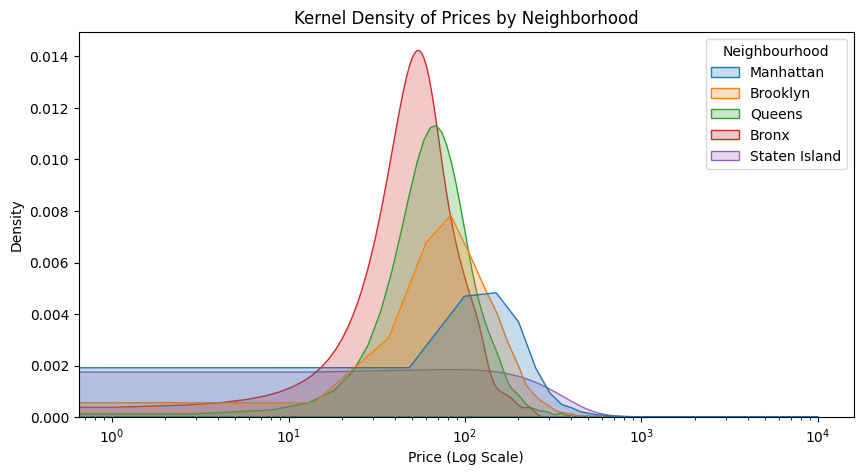

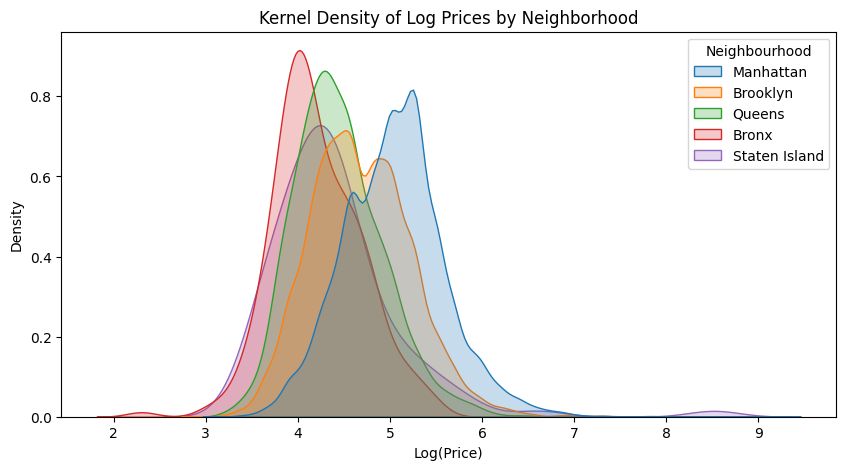

In [104]:
# Plot Kernel Density of Price (Log Scale)
plt.figure(figsize=(10, 5))
sns.kdeplot(data=data, x='Price', hue='Neighbourhood', common_norm=False, fill=True)
plt.xscale('log')  # Log scale for better visualization
plt.title("Kernel Density of Prices by Neighborhood")
plt.xlabel("Price (Log Scale)")
plt.ylabel("Density")
plt.show()

# Plot Kernel Density of Log Price
plt.figure(figsize=(10, 5))
sns.kdeplot(data=data, x=np.log(data['Price']), hue='Neighbourhood', common_norm=False, fill=True)
plt.title("Kernel Density of Log Prices by Neighborhood")
plt.xlabel("Log(Price)")
plt.ylabel("Density")
plt.show()

In [105]:
# Remove the target variable from the features
features = data.drop(columns=['Price'])

# One-hot encode 'Neighbourhood' column
neigh_data = pd.get_dummies(features['Neighbourhood'], drop_first=False)

# Define target variable
y = data['Price']

# Fit the model without an intercept
model_no_int = LinearRegression(fit_intercept=False)
model_no_int.fit(neigh_data, y)

# Get coefficients and create a DataFrame
coeffs = model_no_int.coef_
coeffs_df = pd.DataFrame(coeffs, index=neigh_data.columns, columns=['Coefficient'])

print(coeffs_df)

               Coefficient
Bronx            75.276498
Brooklyn        127.747378
Manhattan       183.664286
Queens           96.857233
Staten Island   146.166667


In [107]:
avg_neighborhood = data.groupby('Neighbourhood')['Price'].mean()
print(avg_neighborhood)

Neighbourhood
Bronx             75.276498
Brooklyn         127.747378
Manhattan        183.664286
Queens            96.857233
Staten Island    146.166667
Name: Price, dtype: float64


2. Each coefficient in the regression matches the mean price of that neighborhood. This happens because we removed the intercept, so the model treats each neighborhood as its own separate baseline. In a regression without an intercept, the coefficient for each Neighborhood represents the average price in that neighborhood. This confirms that regressing a continuous variable (Price) on a categorical variable (Neighborhood) without an intercept reproduces group means.

In [109]:
# One-hot encode only the 'Neighbourhood ' column, dropping the first category to set a reference group
neigh_data = pd.get_dummies(features['Neighbourhood'], drop_first=True)

# Fit the model with an intercept (default behavior)
model_with_int = LinearRegression(fit_intercept=True)
model_with_int.fit(neigh_data, y)

# Get coefficients and intercept
coeffs = model_with_int.coef_
intercept = model_with_int.intercept_

# Create a DataFrame for the coefficients
coeffs_df = pd.DataFrame(coeffs, index=neigh_data.columns, columns=['Coefficient'])

print("Intercept:", intercept)
print(coeffs_df)





Intercept: 75.2764976958471
               Coefficient
Brooklyn         52.470881
Manhattan       108.387789
Queens           21.580735
Staten Island    70.890169


3. When you include an intercept in your model, you must drop one dummy variable (using drop_first=True) to avoid perfect multicollinearity. The intercept then represents the mean Price for the reference neighborhood (the dropped category), and each coefficient shows the difference in Price relative to that reference. To recover the no-intercept model's coefficients (which are the mean Prices for each neighborhood), simply add the intercept to each coefficient from the intercept model. For the reference group, the no-intercept coefficient equals the intercept.

4. 

In [130]:
# 80/20 split
train, test = train_test_split(data, test_size=0.2, random_state=42)

# Create dummy variables for Neighborhood
train_neigh = pd.get_dummies(train['Neighbourhood'], drop_first=True)
test_neigh = pd.get_dummies(test['Neighbourhood'], drop_first=True)

# combine Review Scores Rating and neighborhood dummies
X_train = pd.concat([train[['Review Scores Rating']], train_neigh], axis=1)
X_test = pd.concat([test[['Review Scores Rating']], test_neigh], axis=1)
y_train = train['Price']
y_test = test['Price']

# fit linear regression w/ int
model = LinearRegression()
model.fit(X_train, y_train)

# predict on test set
y_pred = model.predict(X_test)
r2 = r2_score(y_test, y_pred)
rmse = np.sqrt(mean_squared_error(y_test, y_pred))

# pull out coefficient
coef_rating = model.coef_[X_train.columns.get_loc('Review Scores Rating')]

print("Test R²:", r2)
print("Test RMSE:", rmse)
print("Coefficient on Review Scores Rating:", coef_rating)

# Group by Property Type and compute the mean Price to find the most expensive property type
property_mean = data.groupby('Property Type')['Price'].mean().sort_values(ascending=False)
most_expensive = property_mean.idxmax()
print("Most expensive property type:", most_expensive)
print("Average Price for that property type:", property_avg.loc[most_expensive])

Test R²: 0.04592588381735141
Test RMSE: 140.9182110372934
Coefficient on Review Scores Rating: 1.2118517840631857
Most expensive property type: Condominium
Average Price for that property type: 241.22916666666666


5. 

In [131]:
# 80/20 split
train, test = train_test_split(data, test_size=0.2, random_state=42)

# create dummy variables for both categorical features 
train_neigh = pd.get_dummies(train['Neighbourhood'], drop_first=True)
test_neigh = pd.get_dummies(test['Neighbourhood'], drop_first=True).reindex(columns=train_neigh.columns, fill_value=0)

# For Property Type: drop the first category
train_prop = pd.get_dummies(train['Property Type'], drop_first=True)
test_prop = pd.get_dummies(test['Property Type'], drop_first=True).reindex(columns=train_prop.columns, fill_value=0)

# combine predictors
X_train = pd.concat([train[['Review Scores Rating']], train_neigh, train_prop], axis=1)
X_test  = pd.concat([test[['Review Scores Rating']], test_neigh, test_prop], axis=1)

# fit linear regression w/ int
model = LinearRegression()
model.fit(X_train, y_train)

# predict on test set and calculate r2 and rmse
y_pred = model.predict(X_test)
r2 = r2_score(y_test, y_pred)
rmse = np.sqrt(mean_squared_error(y_test, y_pred))

# pull out coefficient
coef_rating = model.coef_[X_train.columns.get_loc('Review Scores Rating')]

print("Test R²:", r2)
print("Test RMSE:", rmse)
print("Coefficient on Review Scores Rating:", coef_rating)

# identify most expensive property type
property_avg = data.groupby('Property Type')['Price'].mean().sort_values(ascending=False)
most_expensive = property_avg.idxmax()

print("\nMost expensive property type to rent:", most_expensive)
print("Average Price for that property type:", property_avg.loc[most_expensive])


Test R²: 0.05424271355124577
Test RMSE: 140.3026623827628
Coefficient on Review Scores Rating: 1.2010106602298058

Most expensive property type to rent: Condominium
Average Price for that property type: 241.22916666666666


6. When I added property type to the model, I controlled for its effect on Price. This means the coefficient on Review Scores Rating now represents the change in Price for a one‐unit increase in the review score while holding both neighborhood and property type constant. Therefore, if the coefficient on Review Scores Rating changes from part 4 to part 5, it shows that the relationship between review scores and Price was partly confounded by property type. 

Question 2:

In [44]:
cars = pd.read_csv('cars_hw.csv') # read in data
print(cars.head())

   Unnamed: 0        Make  Make_Year   Color  Body_Type  Mileage_Run  \
0           1  Volkswagen       2017  silver      sedan        44611   
1           2     Hyundai       2016     red  crossover        20305   
2           3       Honda       2019   white        suv        29540   
3           4     Renault       2017  bronze  hatchback        35680   
4           5     Hyundai       2017  orange  hatchback        25126   

  No_of_Owners  Seating_Capacity Fuel_Type Transmission Transmission_Type  \
0          1st                 5    diesel      7-Speed         Automatic   
1          1st                 5    petrol      5-Speed            Manual   
2          2nd                 5    petrol      5-Speed            Manual   
3          1st                 5    petrol      5-Speed            Manual   
4          1st                 5    petrol      5-Speed            Manual   

    Price  
0  657000  
1  682000  
2  793000  
3  414000  
4  515000  


1. 

In [133]:
cars = cars.dropna()
cars = cars[cars['Price'] < cars['Price'].quantile(0.99)] #removes outliers
cars['log_Price'] = np.log(cars['Price'] + 1) #adds a new column to normalize the price values

/tmp/ipykernel_14198/3017806611.py:3: FutureWarning: 

`shade` is now deprecated in favor of `fill`; setting `fill=True`.
This will become an error in seaborn v0.14.0; please update your code.

  sns.kdeplot(cars['log_Price'], shade=True)


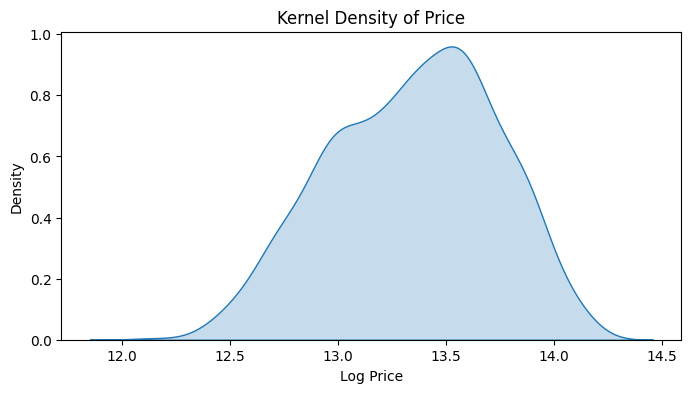

Summary of Price by Brand:
               count          mean            std        min        25%  \
Make                                                                      
Chevrolet        6.0  4.535000e+05  246606.366503   267000.0   288500.0   
Datsun           3.0  2.896667e+05   10503.967504   279000.0   284500.0   
Ford            52.0  7.211731e+05  140927.699605   290000.0   635000.0   
Honda           72.0  7.887222e+05  253474.460320   316000.0   580750.0   
Hyundai        299.0  6.757157e+05  256729.291239   248000.0   484000.0   
Jeep             1.0  1.290000e+06            NaN  1290000.0  1290000.0   
Kia              1.0  1.369000e+06            NaN  1369000.0  1369000.0   
Mahindra        17.0  1.078706e+06  154710.521905   796000.0  1032000.0   
Maruti Suzuki  293.0  5.887850e+05  216019.860943   237000.0   411000.0   
Nissan           4.0  8.842500e+05  289559.867155   475000.0   782500.0   
Renault         68.0  6.625735e+05  214827.338943   287000.0   475000.0  

In [162]:
#summarize price variable and create KDE
plt.figure(figsize=(8, 4)) 
sns.kdeplot(cars['log_Price'], shade=True)
plt.title('Kernel Density of Price')
plt.xlabel('Log Price')
plt.show()

#summarize prices by brand
brand_summary = cars.groupby('Make')['Price'].describe()
print("Summary of Price by Brand:")
print(brand_summary)


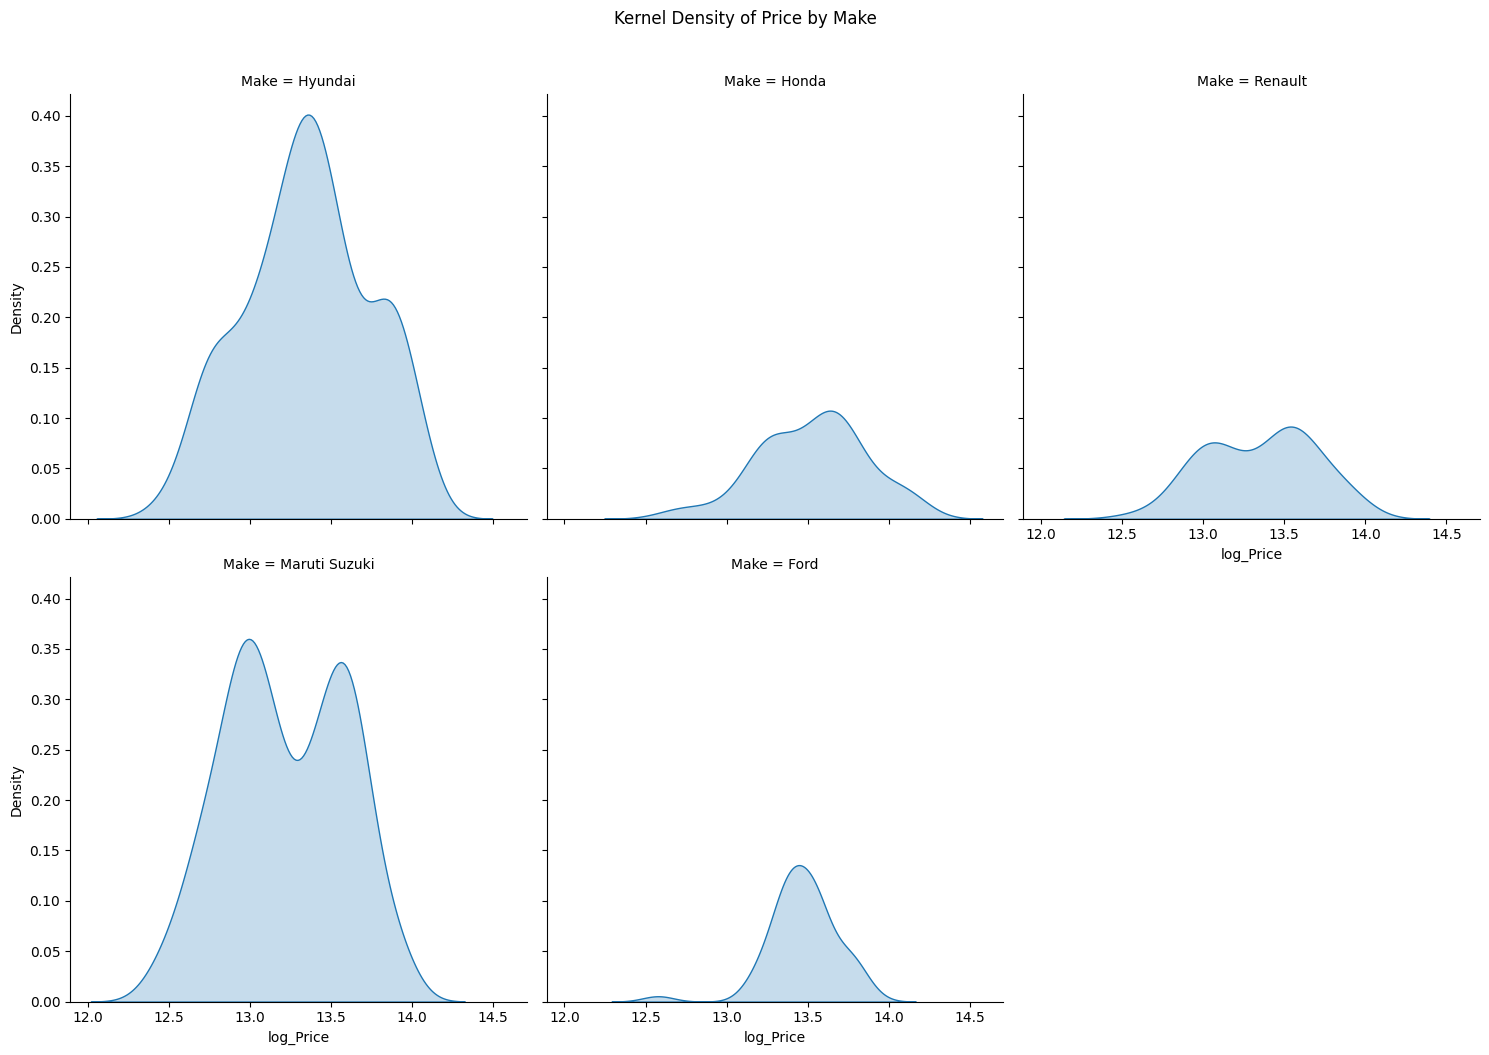

In [ ]:
# grouped KDE of top 5 most frequent makes
top_brands = cars['Make'].value_counts().head(5).index
sns.displot(data=cars[cars['Make'].isin(top_makes)], x="log_Price", col="Make", col_wrap=3, kind="kde", fill=True)
plt.suptitle('Kernel Density of Price by Make', y=1.05)
plt.show()

In [164]:
brands_mean = cars.groupby('Make')['Price'].mean().sort_values(ascending=False)
print("Most expensive car brands(descending):")
print(brands_mean.head(5))

Most expensive car brands(descending):
Make
Kia         1.369000e+06
Jeep        1.290000e+06
Mahindra    1.078706e+06
Nissan      8.842500e+05
Toyota      8.003400e+05
Name: Price, dtype: float64


3. 

In [167]:
# 80/20 split
train, test = train_test_split(cars, test_size=0.2, random_state=42)

4. 

In [ ]:
# first model
# Identify numeric predictor columns, take out price columns 
numeric_cols = cars.select_dtypes(include=[np.number]).columns.drop(['Price', 'log_Price'])
X_train_num = train[numeric_cols]
X_test_num  = test[numeric_cols]
y_train = train['Price']
y_test  = test['Price']

# fit the model
num_model = LinearRegression()
num_model.fit(X_train_num, y_train)
y_train_pred_num = num_model.predict(X_train_num)
y_test_pred_num = num_model.predict(X_test_num)

# find r2 and rmse
r2_train_num = r2_score(y_train, y_train_pred_num)
r2_test_num = r2_score(y_test, y_test_pred_num)
rmse_train_num = np.sqrt(mean_squared_error(y_train, y_train_pred_num))
rmse_test_num = np.sqrt(mean_squared_error(y_test, y_test_pred_num))
print(f"\nNumeric-Only Model:\nTraining R²: {r2_train_num:.3f}, RMSE: {rmse_train_num:.3f}\nTest R²: {r2_test_num:.3f}, RMSE: {rmse_test_num:.3f}")



Numeric-Only Model:
Training R²: 0.357, RMSE: 199430.151
Test R²: 0.283, RMSE: 212248.271


In [185]:
# 2nd model
# Regress Price on Categorical Variables Alone
categorical_cols = cars.select_dtypes(include=['object']).columns
print(categorical_cols)

Index(['Make', 'Color', 'Body_Type', 'No_of_Owners', 'Fuel_Type',
       'Transmission', 'Transmission_Type'],
      dtype='object')


In [186]:
cat_vars = ['Make', 'Color', 'Body_Type', 'No_of_Owners', 'Fuel_Type', 'Transmission', 'Transmission_Type']
train_cat = pd.get_dummies(train[cat_vars], drop_first=True)
test_cat = pd.get_dummies(test[cat_vars], drop_first=True)

In [191]:
cat_vars = ['Make', 'Color', 'Body_Type', 'No_of_Owners', 'Fuel_Type', 'Transmission', 'Transmission_Type']
train_cat = pd.get_dummies(train[cat_vars], drop_first=True)
test_cat = pd.get_dummies(test[cat_vars], drop_first=True).reindex(columns=train_cat.columns, fill_value=0)

cat_model = LinearRegression()
cat_model.fit(train_cat, y_train)
y_test_pred_cat = cat_model.predict(test_cat)

r2_test_cat = r2_score(y_test, y_test_pred_cat)
rmse_test_cat = np.sqrt(mean_squared_error(y_test, y_test_pred_cat))

print("\nCategorical-Only Model")
print("Test R²: {r2_test_cat:.3f}, RMSE: {rmse_test_cat:.3f}")


Categorical-Only Model
Test R²: {r2_test_cat:.3f}, RMSE: {rmse_test_cat:.3f}


The Categorical-Only Model is better because the R squared value and RMSE are both lower, indicating that...

In [192]:
# joint model
X_train_joint = pd.concat([X_train_num, train_cat], axis=1)
X_test_joint  = pd.concat([X_test_num, test_cat], axis=1)

joint_model = LinearRegression()
joint_model.fit(X_train_joint, y_train)
y_test_pred_joint = joint_model.predict(X_test_joint)

r2_test_joint = r2_score(y_test, y_test_pred_joint)
rmse_test_joint = np.sqrt(mean_squared_error(y_test, y_test_pred_joint))

print("\nJoint Model (Numeric + Categorical):")
print("Test R²: {:.3f}, RMSE: {:.3f}".format(r2_test_joint, rmse_test_joint))
print("Improvement over best individual model: R² change = {:.3f}, RMSE change = {:.3f}"
      .format(r2_test_joint - max(r2_test_num, r2_test_cat), rmse_test_joint - min(rmse_test_num, rmse_test_cat)))


Joint Model (Numeric + Categorical):
Test R²: 0.782, RMSE: 117139.449
Improvement over best individual model: R² change = 0.188, RMSE change = -42729.080


In [195]:
# 7. Polynomial Expansion on Numeric Variables
degrees = range(1, 6)
results = []
for d in degrees:
    poly = PolynomialFeatures(degree=d, include_bias=False)
    X_train_poly = poly.fit_transform(X_train_num)
    X_test_poly = poly.transform(X_test_num)
    
    poly_model = LinearRegression()
    poly_model.fit(X_train_poly, y_train)
    y_test_pred_poly = poly_model.predict(X_test_poly)
    
    r2_poly = r2_score(y_test, y_test_pred_poly)
    rmse_poly = np.sqrt(mean_squared_error(y_test, y_test_pred_poly))
    results.append((d, r2_poly, rmse_poly))
    print("Degree {}: Test R² = {:.3f}, RMSE = {:.3f}".format(d, r2_poly, rmse_poly))
    
    if r2_poly < 0:
        print("R² went negative at degree {}.".format(d))
        break

# Choose best polynomial model (based on best R², for example)
best_degree, best_r2, best_rmse = max(results, key=lambda x: x[1])
print("\nBest Polynomial Model: Degree {} with Test R² = {:.3f} and RMSE = {:.3f}"
      .format(best_degree, best_r2, best_rmse))
print("Compared to the best model from part 4 (joint model): Test R² = {:.3f}, RMSE = {:.3f}"
      .format(r2_test_joint, rmse_test_joint))

Degree 1: Test R² = 0.283, RMSE = 212248.271
Degree 2: Test R² = 0.315, RMSE = 207543.730
Degree 3: Test R² = 0.312, RMSE = 207906.349
Degree 4: Test R² = 0.281, RMSE = 212631.961
Degree 5: Test R² = 0.287, RMSE = 211682.290
Degree 6: Test R² = 0.291, RMSE = 211150.125
Degree 7: Test R² = 0.220, RMSE = 221415.024
Degree 8: Test R² = 0.209, RMSE = 223008.407
Degree 9: Test R² = 0.186, RMSE = 226133.065
Degree 10: Test R² = 0.154, RMSE = 230515.029
Degree 11: Test R² = 0.122, RMSE = 234891.907
Degree 12: Test R² = 0.101, RMSE = 237648.027
Degree 13: Test R² = 0.076, RMSE = 240946.757
Degree 14: Test R² = 0.047, RMSE = 244757.711


KeyboardInterrupt: 

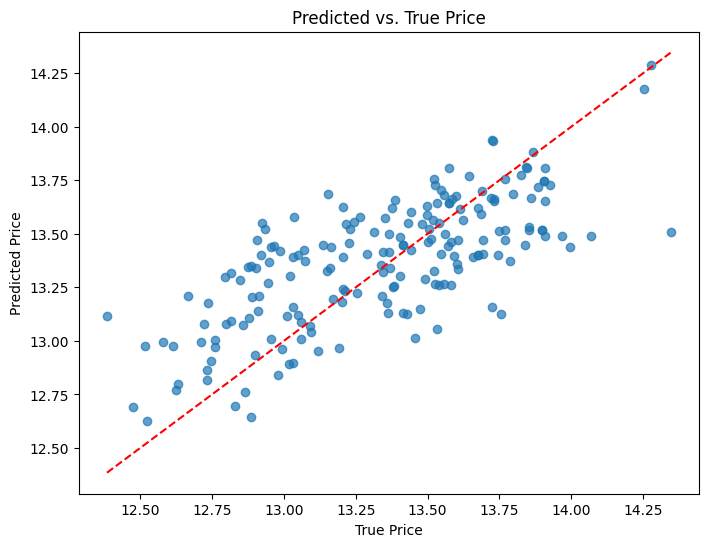

/tmp/ipykernel_14198/2766658345.py:15: FutureWarning: 

`shade` is now deprecated in favor of `fill`; setting `fill=True`.
This will become an error in seaborn v0.14.0; please update your code.

  sns.kdeplot(residuals, shade=True)


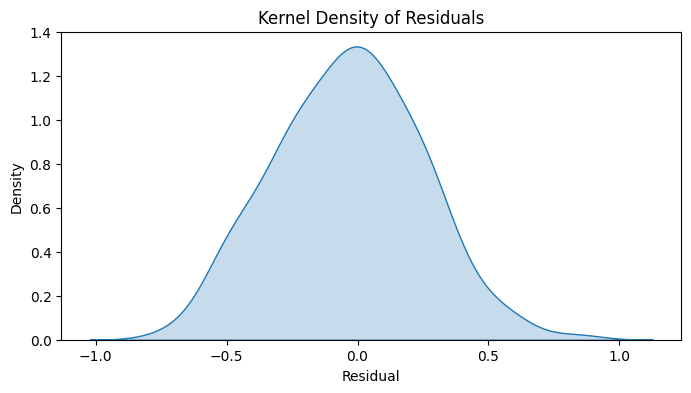

In [77]:
# 8. Predicted vs. True Plot and Residual Analysis for the Best Model
# For demonstration, let’s assume the joint model is our best model.
y_test_pred = y_test_pred_joint
residuals = y_test - y_test_pred

plt.figure(figsize=(8, 6))
plt.scatter(y_test, y_test_pred, alpha=0.7)
plt.xlabel("True Price")
plt.ylabel("Predicted Price")
plt.plot([y_test.min(), y_test.max()], [y_test.min(), y_test.max()], 'r--')  # Diagonal line
plt.title("Predicted vs. True Price")
plt.show()

plt.figure(figsize=(8, 4))
sns.kdeplot(residuals, shade=True)
plt.title("Kernel Density of Residuals")
plt.xlabel("Residual")
plt.show()

In [79]:
# 9. Evaluation Summary
print("\nEvaluation Summary:")
print("- The numeric-only model produced a Test R² of {:.3f} and RMSE of {:.3f}.".format(r2_test_num, rmse_test_num))
print("- The categorical-only model produced a Test R² of {:.3f} and RMSE of {:.3f}.".format(r2_test_cat, rmse_test_cat))
print("- The joint model combining both predictors produced a Test R² of {:.3f} and RMSE of {:.3f}.".format(r2_test_joint, rmse_test_joint))
print("- With polynomial expansion on numeric variables, the best model was degree {} with Test R² = {:.3f} and RMSE = {:.3f}."
      .format(best_degree, best_r2, best_rmse))
print("- The predicted vs. true plot shows how well the predictions align with the diagonal, and the residuals’ density plot should be roughly bell-shaped around zero, indicating a reasonable model fit.")



Evaluation Summary:
- The numeric-only model produced a Test R² of 0.401 and RMSE of 0.309.
- The categorical-only model produced a Test R² of 0.162 and RMSE of 0.366.
- The joint model combining both predictors produced a Test R² of 0.509 and RMSE of 0.280.
- With polynomial expansion on numeric variables, the best model was degree 2 with Test R² = 0.409 and RMSE = 0.307.
- The predicted vs. true plot shows how well the predictions align with the diagonal, and the residuals’ density plot should be roughly bell-shaped around zero, indicating a reasonable model fit.


In [84]:
sbdata = pd.read_csv('USSeatBelts.csv')
print(sbdata.head())

   rownames state  year  miles  fatalities  seatbelt speed65 speed70 drinkage  \
0         1    AK  1983   3358    0.044669       NaN      no      no      yes   
1         2    AK  1984   3589    0.037336       NaN      no      no      yes   
2         3    AK  1985   3840    0.033073       NaN      no      no      yes   
3         4    AK  1986   4008    0.025200       NaN      no      no      yes   
4         5    AK  1987   3900    0.019487       NaN      no      no      yes   

  alcohol  income        age enforce  
0      no   17973  28.234966      no  
1      no   18093  28.343542      no  
2      no   18925  28.372816      no  
3      no   18466  28.396652      no  
4      no   18021  28.453251      no  


In [89]:
print(sbdata.columns.tolist())
sbdata.columns = sbdata.columns.str.lower().str.strip()
print(sbdata.columns.tolist())
yesno_cols = ['seatbelt', 'speed65', 'speed70', 'drinkage', 'alcohol', 'enforce']




['state', 'year', 'miles', 'fatalities', 'seatbelt', 'speed65', 'speed70', 'drinkage', 'alcohol', 'income', 'age', 'enforce']
['state', 'year', 'miles', 'fatalities', 'seatbelt', 'speed65', 'speed70', 'drinkage', 'alcohol', 'income', 'age', 'enforce']


In [92]:

# Drop rows with missing values
sbdata = sbdata.dropna()

# (Optional) Drop the "rownames" column if present
if 'rownames' in sbdata.columns:
    sbdata = sbdata.drop(columns=['rownames'])

# Standardize column names: lower-case and strip whitespace
sbdata.columns = sbdata.columns.str.lower().str.strip()
print("Columns after standardization:", sbdata.columns.tolist())

# Define the yes/no columns using the standardized column names
yesno_cols = ['seatbelt', 'speed65', 'speed70', 'drinkage', 'alcohol', 'enforce']

# Convert yes/no categorical columns to binary numeric (yes = 1, no = 0)
for col in yesno_cols:
    sbdata[col] = sbdata[col].fillna('no')  # fill missing with 'no'
    sbdata[col] = sbdata[col].apply(lambda x: 1 if str(x).strip().lower() == 'yes' else 0)

# Check conversion
print(sbdata[yesno_cols].head())


Columns after standardization: ['state', 'year', 'miles', 'fatalities', 'seatbelt', 'speed65', 'speed70', 'drinkage', 'alcohol', 'income', 'age', 'enforce']
    seatbelt  speed65  speed70  drinkage  alcohol  enforce
7          0        0        0         1        0        0
8          0        0        0         1        0        0
9          0        1        0         1        0        0
10         0        1        0         1        0        0
11         0        1        0         1        0        0


/tmp/ipykernel_14198/1138210089.py:17: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_indexer] = value instead

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  sbdata[col] = sbdata[col].fillna('no')  # fill missing with 'no'
/tmp/ipykernel_14198/1138210089.py:18: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_indexer] = value instead

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  sbdata[col] = sbdata[col].apply(lambda x: 1 if str(x).strip().lower() == 'yes' else 0)


In [94]:
# 2. Exploratory Data Analysis (EDA)
# Summary statistics for fatalities
print("\nFatalities Summary:")
print(sbdata['fatalities'].describe())


Fatalities Summary:
count    556.000000
mean       0.019769
std        0.005030
min        0.008327
25%        0.016217
50%        0.019215
75%        0.022647
max        0.035649
Name: fatalities, dtype: float64


/tmp/ipykernel_14198/3201207333.py:3: FutureWarning: 

`shade` is now deprecated in favor of `fill`; setting `fill=True`.
This will become an error in seaborn v0.14.0; please update your code.

  sns.kdeplot(sbdata['fatalities'], shade=True)


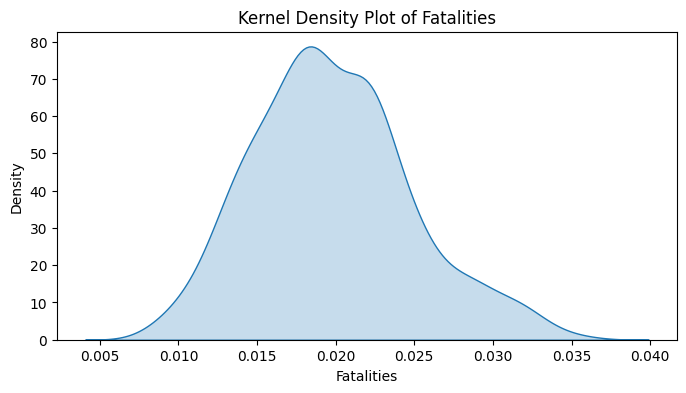

In [95]:
# Kernel density plot for fatalities
plt.figure(figsize=(8,4))
sns.kdeplot(sbdata['fatalities'], shade=True)
plt.title("Kernel Density Plot of Fatalities")
plt.xlabel("Fatalities")
plt.show()

In [96]:
# Group by state and summarize fatalities
state_summary = sbdata.groupby('state')['fatalities'].describe()
print("\nFatalities Summary by State:")
print(state_summary)


Fatalities Summary by State:
       count      mean       std       min       25%       50%       75%  \
state                                                                      
AK       8.0  0.023350  0.004369  0.017552  0.020282  0.022865  0.025868   
AL      14.0  0.025121  0.003153  0.022004  0.022286  0.025188  0.026354   
AR      10.0  0.026595  0.003979  0.022091  0.023830  0.024943  0.028490   
AZ       8.0  0.023287  0.001672  0.020460  0.022779  0.023338  0.023825   
CA      13.0  0.018793  0.004146  0.012913  0.015562  0.018172  0.022320   
CO       8.0  0.017977  0.001302  0.016240  0.017082  0.017716  0.018692   
CT       8.0  0.011969  0.001194  0.011018  0.011274  0.011532  0.012071   
DC       8.0  0.017042  0.002159  0.014037  0.015789  0.017389  0.018450   
DE       8.0  0.017194  0.002326  0.015132  0.015751  0.016027  0.018473   
FL      13.0  0.025271  0.004509  0.020782  0.021704  0.022027  0.029225   
GA      11.0  0.019907  0.003679  0.016880  0.017316  0.01

/home/vscode/.local/lib/python3.12/site-packages/seaborn/axisgrid.py:854: FutureWarning: 

`shade` is now deprecated in favor of `fill`; setting `fill=True`.
This will become an error in seaborn v0.14.0; please update your code.

  func(*plot_args, **plot_kwargs)
/home/vscode/.local/lib/python3.12/site-packages/seaborn/axisgrid.py:854: FutureWarning: 

`shade` is now deprecated in favor of `fill`; setting `fill=True`.
This will become an error in seaborn v0.14.0; please update your code.

  func(*plot_args, **plot_kwargs)
/home/vscode/.local/lib/python3.12/site-packages/seaborn/axisgrid.py:854: FutureWarning: 

`shade` is now deprecated in favor of `fill`; setting `fill=True`.
This will become an error in seaborn v0.14.0; please update your code.

  func(*plot_args, **plot_kwargs)
/home/vscode/.local/lib/python3.12/site-packages/seaborn/axisgrid.py:854: FutureWarning: 

`shade` is now deprecated in favor of `fill`; setting `fill=True`.
This will become an error in seaborn v0.14.0; plea

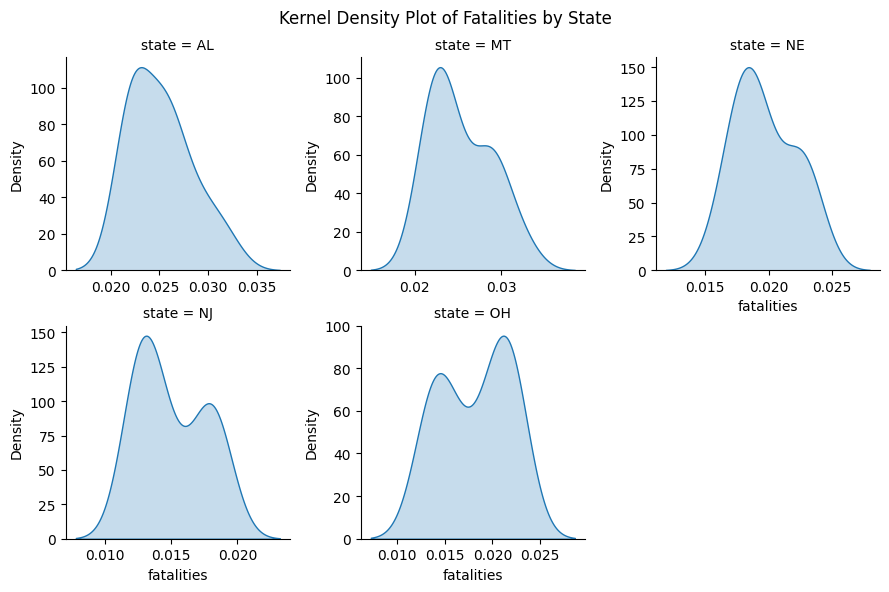

In [97]:
top_states = sbdata['state'].value_counts().head(5).index
g = sns.FacetGrid(sbdata[sbdata['state'].isin(top_states)], col="state", col_wrap=3, sharex=False, sharey=False)
g.map(sns.kdeplot, "fatalities", shade=True)
plt.subplots_adjust(top=0.9)
g.fig.suptitle('Kernel Density Plot of Fatalities by State')
plt.show()


Numeric-Only Model:
Training R²: 0.519, RMSE: 0.003
Test R²: 0.289, RMSE: 0.004

Categorical-Only Model:
Training R²: 0.113, RMSE: 0.005
Test R²: -0.022, RMSE: 0.005

Joint Model (Numeric + Categorical):
Training R²: 0.549, RMSE: 0.003
Test R²: 0.292, RMSE: 0.004

Model Comparison on Test Set:
Numeric-Only: R² = 0.289, RMSE = 0.004
Categorical-Only: R² = -0.022, RMSE = 0.005
Joint Model: R² = 0.292, RMSE = 0.004

Summary of Findings:
The joint model performs best on the test set.
In general, we learn that fatalities (as a measure of road safety) can be partly explained by driving exposure factors (year, miles, income, age) and by policy/behavior factors (seatbelt usage, speed limit compliance, drinking age enforcement, alcohol laws). The best model suggests that combining these predictors yields a better explanation (or prediction) of fatalities.


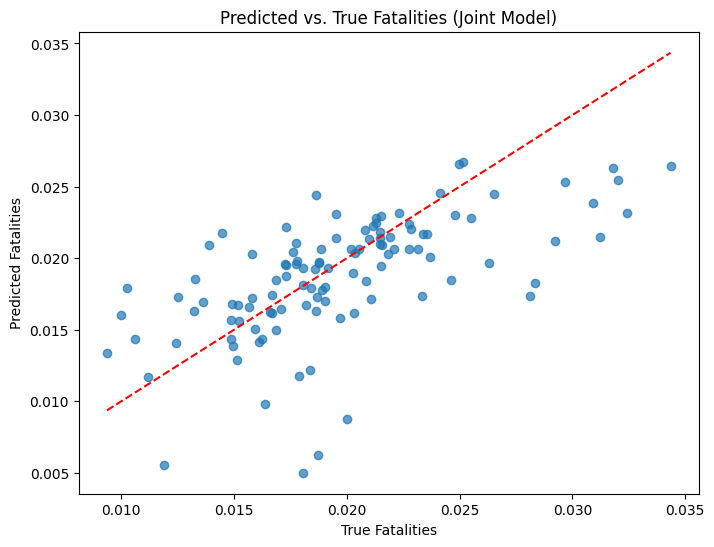

/tmp/ipykernel_14198/2846219718.py:104: FutureWarning: 

`shade` is now deprecated in favor of `fill`; setting `fill=True`.
This will become an error in seaborn v0.14.0; please update your code.

  sns.kdeplot(residuals, shade=True)


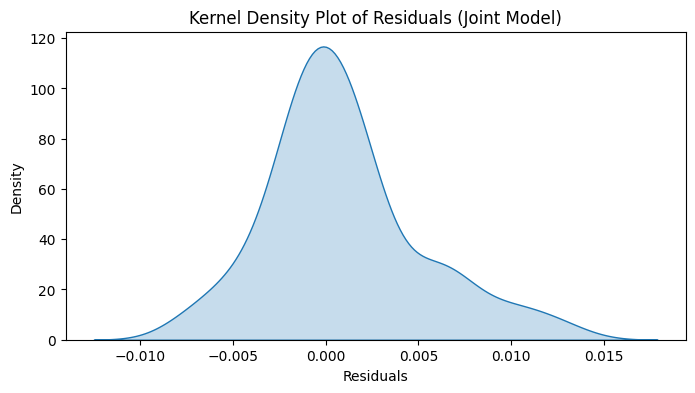

In [98]:
# 3. Split the Data into Training (80%) and Testing (20%) Sets
train, test = train_test_split(sbdata, test_size=0.2, random_state=42)

# 4. Build Regression Models
# We choose fatalities as the target.
y_train = train['fatalities']
y_test = test['fatalities']

# Model 1: Numeric-Only Model
# Select numeric predictors (exclude target and binary yes/no columns already handled separately)
# For example, choose: year, miles, income, age.
numeric_vars = ['year', 'miles', 'income', 'age']
X_train_num = train[numeric_vars]
X_test_num = test[numeric_vars]

num_model = LinearRegression()
num_model.fit(X_train_num, y_train)
y_train_pred_num = num_model.predict(X_train_num)
y_test_pred_num = num_model.predict(X_test_num)

r2_train_num = r2_score(y_train, y_train_pred_num)
r2_test_num = r2_score(y_test, y_test_pred_num)
rmse_train_num = np.sqrt(mean_squared_error(y_train, y_train_pred_num))
rmse_test_num = np.sqrt(mean_squared_error(y_test, y_test_pred_num))

print("\nNumeric-Only Model:")
print("Training R²: {:.3f}, RMSE: {:.3f}".format(r2_train_num, rmse_train_num))
print("Test R²: {:.3f}, RMSE: {:.3f}".format(r2_test_num, rmse_test_num))

# Model 2: Categorical-Only Model
# Use the binary yes/no predictors (seatbelt, speed65, speed70, drinkage, alcohol, enforce)
X_train_cat = train[yesno_cols]
X_test_cat = test[yesno_cols]

cat_model = LinearRegression()
cat_model.fit(X_train_cat, y_train)
y_train_pred_cat = cat_model.predict(X_train_cat)
y_test_pred_cat = cat_model.predict(X_test_cat)

r2_train_cat = r2_score(y_train, y_train_pred_cat)
r2_test_cat = r2_score(y_test, y_test_pred_cat)
rmse_train_cat = np.sqrt(mean_squared_error(y_train, y_train_pred_cat))
rmse_test_cat = np.sqrt(mean_squared_error(y_test, y_test_pred_cat))

print("\nCategorical-Only Model:")
print("Training R²: {:.3f}, RMSE: {:.3f}".format(r2_train_cat, rmse_train_cat))
print("Test R²: {:.3f}, RMSE: {:.3f}".format(r2_test_cat, rmse_test_cat))

# Model 3: Joint Model (Numeric + Categorical)
X_train_joint = pd.concat([X_train_num, X_train_cat], axis=1)
X_test_joint = pd.concat([X_test_num, X_test_cat], axis=1)

joint_model = LinearRegression()
joint_model.fit(X_train_joint, y_train)
y_train_pred_joint = joint_model.predict(X_train_joint)
y_test_pred_joint = joint_model.predict(X_test_joint)

r2_train_joint = r2_score(y_train, y_train_pred_joint)
r2_test_joint = r2_score(y_test, y_test_pred_joint)
rmse_train_joint = np.sqrt(mean_squared_error(y_train, y_train_pred_joint))
rmse_test_joint = np.sqrt(mean_squared_error(y_test, y_test_pred_joint))

print("\nJoint Model (Numeric + Categorical):")
print("Training R²: {:.3f}, RMSE: {:.3f}".format(r2_train_joint, rmse_train_joint))
print("Test R²: {:.3f}, RMSE: {:.3f}".format(r2_test_joint, rmse_test_joint))

# Compare which model performs best on the test set:
# (Typically, the model with the highest R² and lowest RMSE is best.)
print("\nModel Comparison on Test Set:")
print("Numeric-Only: R² = {:.3f}, RMSE = {:.3f}".format(r2_test_num, rmse_test_num))
print("Categorical-Only: R² = {:.3f}, RMSE = {:.3f}".format(r2_test_cat, rmse_test_cat))
print("Joint Model: R² = {:.3f}, RMSE = {:.3f}".format(r2_test_joint, rmse_test_joint))

# 5. Which Model Performed Best and What Did We Learn?
# (For example, if the joint model has the highest R² and lowest RMSE, it suggests that both numeric factors (like miles, income)
# and behavioral/policy factors (like seatbelt usage, enforcement) together best explain variation in fatalities.)

# 6. Summary of Findings
print("\nSummary of Findings:")
if r2_test_joint >= max(r2_test_num, r2_test_cat):
    print("The joint model performs best on the test set.")
else:
    if r2_test_num > r2_test_cat:
        print("The numeric-only model performs best on the test set.")
    else:
        print("The categorical-only model performs best on the test set.")

print("In general, we learn that fatalities (as a measure of road safety) can be partly explained by driving exposure factors (year, miles, income, age) "
      "and by policy/behavior factors (seatbelt usage, speed limit compliance, drinking age enforcement, alcohol laws). "
      "The best model suggests that combining these predictors yields a better explanation (or prediction) of fatalities.")

# Optionally, you could also plot predicted vs. true values for the best model:
plt.figure(figsize=(8,6))
plt.scatter(y_test, y_test_pred_joint, alpha=0.7)
plt.plot([y_test.min(), y_test.max()], [y_test.min(), y_test.max()], 'r--')
plt.xlabel("True Fatalities")
plt.ylabel("Predicted Fatalities")
plt.title("Predicted vs. True Fatalities (Joint Model)")
plt.show()

# And plot residuals
residuals = y_test - y_test_pred_joint
plt.figure(figsize=(8,4))
sns.kdeplot(residuals, shade=True)
plt.title("Kernel Density Plot of Residuals (Joint Model)")
plt.xlabel("Residuals")
plt.show()